In [2]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #bee7ff; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #1e1a66">Reduced Order Modeling on Stokes Equations</h3>
</div>

Imports:

In [4]:
from scipy.sparse.linalg import spsolve
import numpy as np
import seaborn as sns

from Utilities.Stokes_felib import *
from Utilities.Mesh_processing import *
from Utilities.Plot_functions import *

Datasets:

In [12]:
visc_path = os.path.join('Reduced_Order_Modeling', 'Data', 'viscosity_snapshots.npz')
sol_path  = os.path.join('Reduced_Order_Modeling', 'Data', 'stokes_solution_snapshots.npz')

for path in [visc_path, sol_path]:
    print(f"\nFile: {path}")
    with np.load(path) as data:
        for key in data.files:
            print(f"  Key: {key:<20} Shape: {data[key].shape}")


File: Reduced_Order_Modeling/Data/viscosity_snapshots.npz
  Key: v_t_snapshots        Shape: (100, 191488)
  Key: parameters           Shape: (100, 5)
  Key: knots                Shape: (5, 2)
  Key: p_fine               Shape: (96817, 2)
  Key: t_fine               Shape: (191488, 7)
  Key: e_fine               Shape: (288304, 3)

File: Reduced_Order_Modeling/Data/stokes_solution_snapshots.npz
  Key: ux_snapshots         Shape: (100, 96817)
  Key: uy_snapshots         Shape: (100, 96817)
  Key: p_snapshots          Shape: (100, 24473)
  Key: parameters           Shape: (100, 5)
  Key: p_fine               Shape: (96817, 2)
  Key: t_fine               Shape: (191488, 7)
  Key: e_fine               Shape: (288304, 3)
  Key: p_coarse             Shape: (24473, 2)
  Key: t_coarse             Shape: (47872, 7)


---

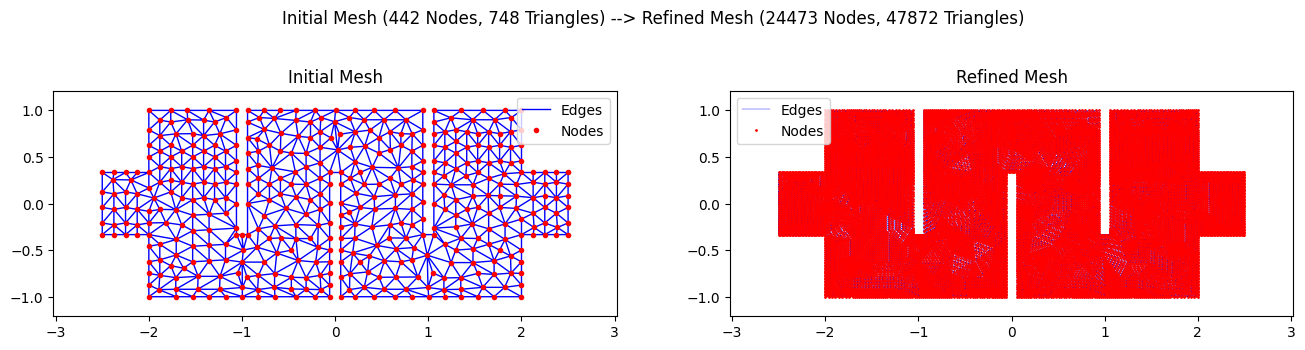

In [11]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(data_path='Meshes/exchanger_device_altered_mesh_data.npz', num_of_refinements=3, 
                                                           plot=True,
                                                           figsize=(16,4))
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

### Viscosity Snapshots

--- GLOBAL STATISTICS ---
Total Snapshots:      100
Elements per Mesh:    191488
Absolute Min ( >0? ): 10.242768
Absolute Max:         199.898669
Global Mean:          104.964117

--- SPATIAL VARIABILITY ---
Highest variability at element 97408 (Std: 54.903198)
Lowest variability is 29.664079

--- INTRINSIC DIMENSIONALITY ---
Modes needed to capture 99.9% of viscosity variance: 5


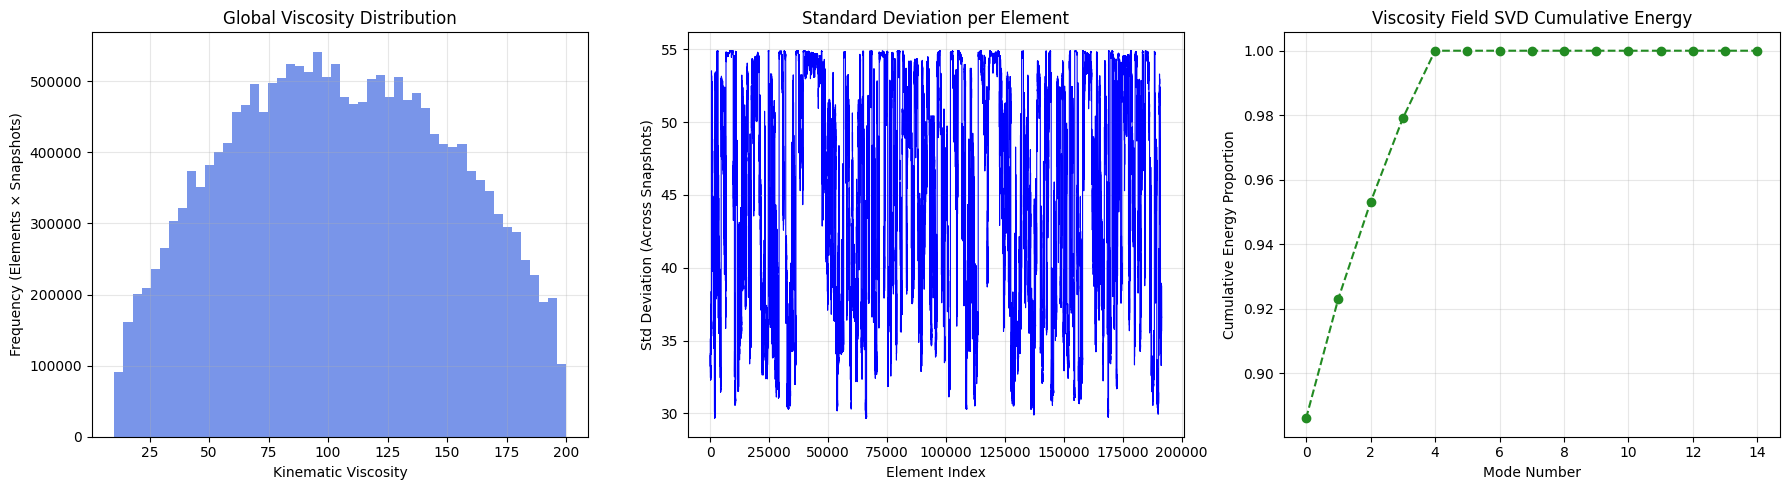

In [9]:
with np.load(visc_path) as data:
    v_t = data['v_t_snapshots'] 

n_snapshots, n_elements = v_t.shape

print("--- GLOBAL STATISTICS ---")
print(f"Total Snapshots:      {n_snapshots}")
print(f"Elements per Mesh:    {n_elements}")
print(f"Absolute Min ( >0? ): {np.min(v_t):.6f}")
print(f"Absolute Max:         {np.max(v_t):.6f}")
print(f"Global Mean:          {np.mean(v_t):.6f}")

element_std = np.std(v_t, axis=0)
max_var_elem = np.argmax(element_std)

print("\n--- SPATIAL VARIABILITY ---")
print(f"Highest variability at element {max_var_elem} (Std: {np.max(element_std):.6f})")
print(f"Lowest variability is {np.min(element_std):.6f}")

# Dimensionality / Complexity
_, S, _ = np.linalg.svd(v_t, full_matrices=False)
energy = np.cumsum(S**2) / np.sum(S**2)
modes_99 = np.searchsorted(energy, 0.999) + 1

print("\n--- INTRINSIC DIMENSIONALITY ---")
print(f"Modes needed to capture 99.9% of viscosity variance: {modes_99}")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(v_t.flatten(), bins=50, color='royalblue', alpha=0.7)
axes[0].set_title("Global Viscosity Distribution")
axes[0].set_xlabel("Kinematic Viscosity")
axes[0].set_ylabel("Frequency (Elements × Snapshots)")
axes[0].grid(alpha=0.3)

axes[1].plot(element_std, color='blue', linewidth=0.8)
axes[1].set_title("Standard Deviation per Element")
axes[1].set_xlabel("Element Index")
axes[1].set_ylabel("Std Deviation (Across Snapshots)")
axes[1].grid(alpha=0.3)

axes[2].plot(energy[:15], marker='o', color='forestgreen', linestyle='--')
axes[2].set_title("Viscosity Field SVD Cumulative Energy")
axes[2].set_xlabel("Mode Number")
axes[2].set_ylabel("Cumulative Energy Proportion")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

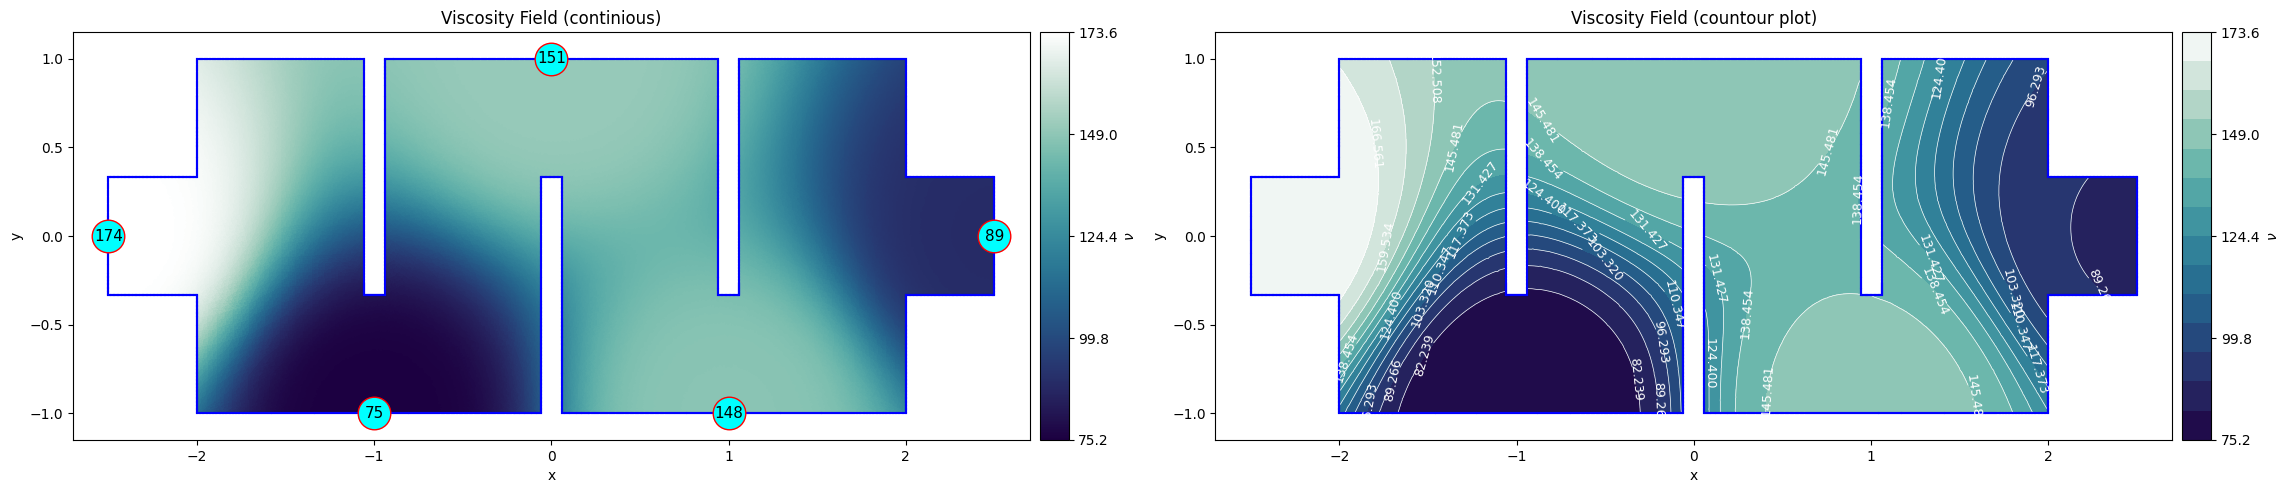

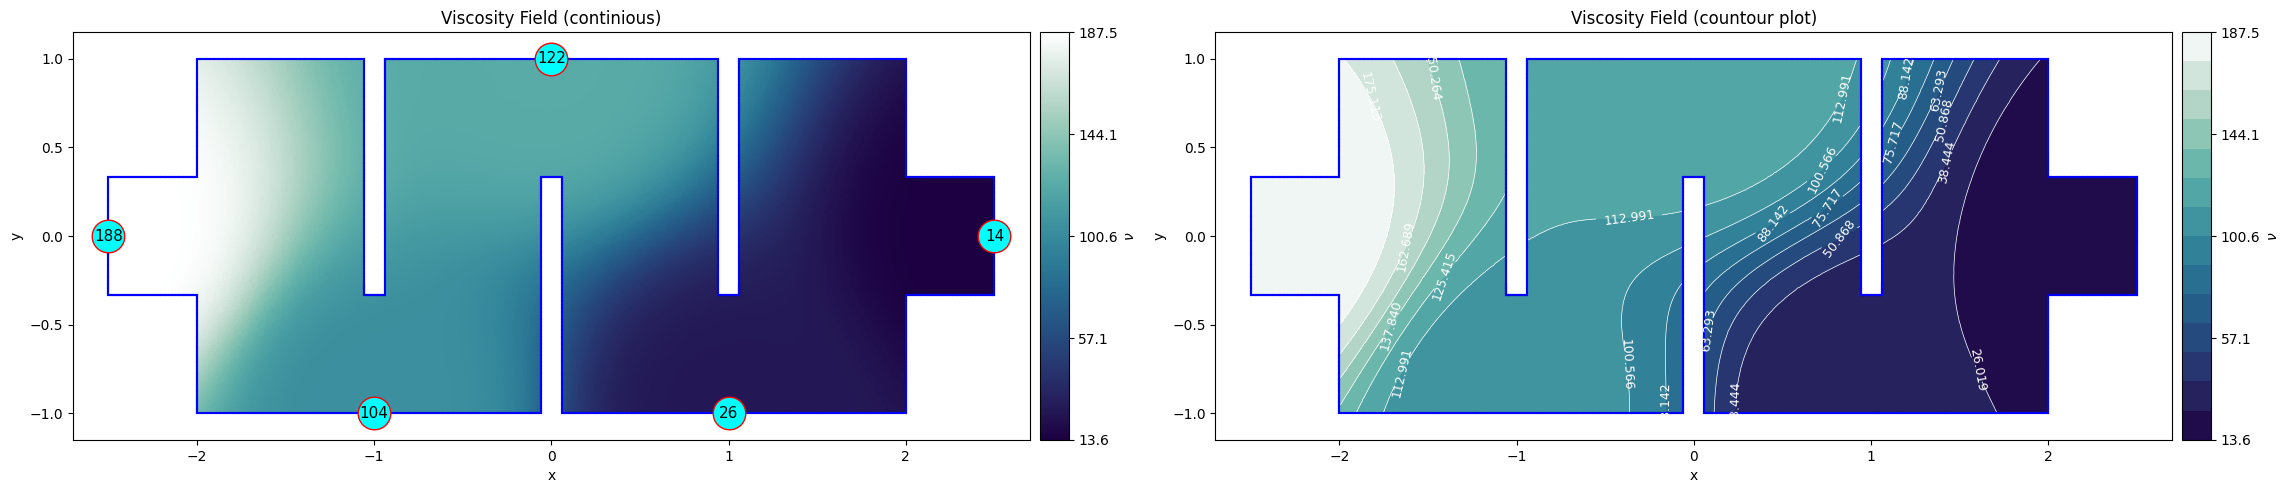

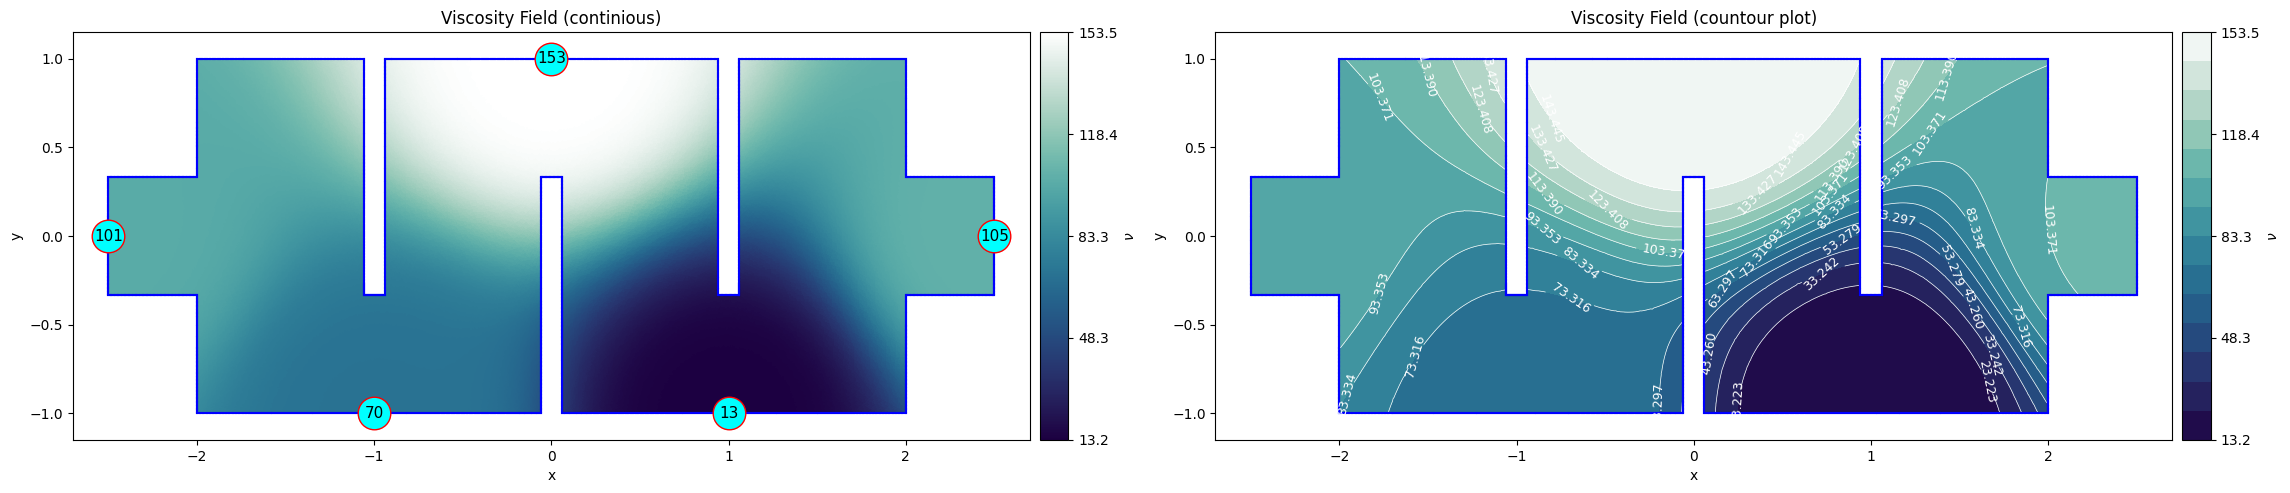

In [17]:
npz_path = os.path.join('Reduced_Order_Modeling', 'Data', 'viscosity_snapshots.npz')
data = np.load(npz_path)

p_fine = data['p_fine']
t_fine = data['t_fine']
e_fine = data['e_fine']
knots  = data['knots']

for snapshot_idx in [3, 7, 9]:
    v_t_snapshot = data['v_t_snapshots'][snapshot_idx]
    params_snapshot = data['parameters'][snapshot_idx]

    nu_KNOTS = {
        'pts': knots,
        'vals': params_snapshot
    }

    plot_viscosity(p_fine, t_fine, e_fine, v_t_snapshot, nu_KNOTS,
                n_levels=15,
                figsize=(23, 10),
                savetype='png')

data.close()


---

### Solution Snapshots

In [10]:
with np.load(sol_path) as data:
    ux = data['ux_snapshots']
    uy = data['uy_snapshots']
    p  = data['p_snapshots']

num_snapshots, Nv = ux.shape
_, Np = p.shape

U_mag = np.sqrt(ux**2 + uy**2)

print("\n" + "=" * 50)
print(" GLOBAL FIELD STATISTICS")
print("=" * 50)
print(f" Total Snapshots:     {num_snapshots}")
print("-" * 50)
print(f" Velocity Mag Min:    {np.min(U_mag):.6f}")
print(f" Velocity Mag Max:    {np.max(U_mag):.6f}")
print(f" Velocity Mag Mean:   {np.mean(U_mag):.6f}")
print("-" * 50)
print(f" Pressure Min:        {np.min(p):.2f}")
print(f" Pressure Max:        {np.max(p):.2f}")
print(f" Pressure Mean:       {np.mean(p):.2f}")
print("=" * 50)


 GLOBAL FIELD STATISTICS
 Total Snapshots:     100
--------------------------------------------------
 Velocity Mag Min:    0.000000
 Velocity Mag Max:    1.605584
 Velocity Mag Mean:   0.565803
--------------------------------------------------
 Pressure Min:        -60451.14
 Pressure Max:        272753.39
 Pressure Mean:       29020.09


Displaying Pre-computed Snapshot: 0
Knot Viscosity Values: [101.98  36.22 101.36  52.3  129.49]


KeyboardInterrupt: 

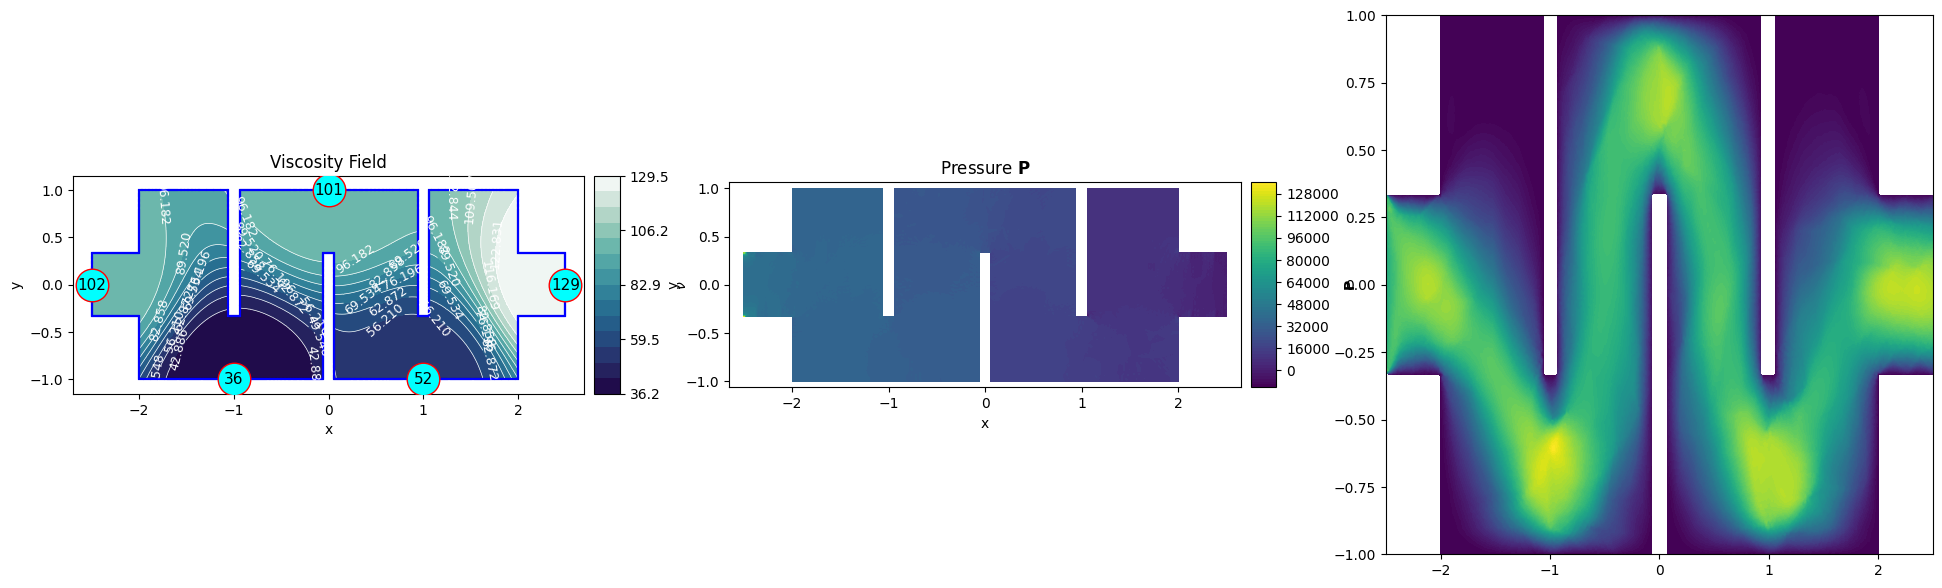

In [ ]:
with np.load(visc_path) as data_v:
    v_t_snapshots = data_v['v_t_snapshots']
    parameters    = data_v['parameters']
    knots         = data_v['knots']

with np.load(sol_path) as data_s:
    ux_snapshots = data_s['ux_snapshots']
    uy_snapshots = data_s['uy_snapshots']
    p_snapshots  = data_s['p_snapshots']

snapshots_to_plot = range(5) 

for i in snapshots_to_plot:
    v_t_snap    = v_t_snapshots[i]  # The element-wise viscosity field
    params_snap = parameters[i]     # The 5 random knot values
    
    ux_snap     = ux_snapshots[i]   # X-velocity field
    uy_snap     = uy_snapshots[i]   # Y-velocity field
    p_snap      = p_snapshots[i]    # Pressure field
    
    # 2. Package the knots dictionary for the plotting function
    nu_KNOTS = {
        'pts': knots,
        'vals': params_snap
    }
    
    print(f"Displaying Pre-computed Snapshot: {i}")
    print(f"Knot Viscosity Values: {np.round(params_snap, 2)}")
    
    plot_combined_solution(
        p_fine=p_fine, t_fine=t_fine, ux=ux_snap, uy=uy_snap,
        p_coarse=p_coarse, t_coarse=t_coarse, p_sol=p_snap,
        p=p_fine, t=t_fine, e=e_fine, nu_T=v_t_snap, nu_KNOTS=nu_KNOTS,
        figsize=(24, 7), 
        savetype='png'
    )

---
# REDUCED ORDER MODEL
---

$$S_u = [\mathbf{u}_1, \mathbf{u}_2, \dots, \mathbf{u}_N]$$
$$S_p = [\mathbf{p}_1, \mathbf{p}_2, \dots, \mathbf{p}_N]$$